# Risk Factor Semantic Analysis

**Project:** Financial Planning & Analysis Intelligence Platform

**Notebook:** `06-risk-factor-semantic-analysis.ipynb`

In [1]:
# ==========================================
# Notebook 06
# Risk Factor Semantic Analysis
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [8]:
financial_df = pd.read_csv("../data/financial_guidance_dataset.csv")

financial_df.head()

,ticker,quarter,revenue_million,gross_margin_pct,operating_income_million,net_income_million,eps,earnings_call,risk_factors,mda_section,combined_text,clean_text,character_count,sentences,chunks,sentiment,confidence,weighted_sentiment,guidance_score,positive_guidance_score
0,ABC,2023-Q1,120,58,22,16,1.20,\n Demand remained strong across enterp...,\n Inflation remains a concern.\n ...,\n Management believes demand trends re...,\n Demand remained strong across enterp...,Demand remained strong across enterprise custo...,299,['Demand remained strong across enterprise cus...,['Demand remained strong across enterprise cus...,positive,0.956167,0.956167,1,1
1,ABC,2023-Q2,128,60,25,18,1.35,\n Enterprise adoption accelerated.\n ...,\n Competitive pressure exists.\n ...,\n New product launches contributed pos...,\n Enterprise adoption accelerated.\n ...,Enterprise adoption accelerated. Pricing press...,239,"['Enterprise adoption accelerated.', 'Pricing ...",['Enterprise adoption accelerated. Pricing pre...,positive,0.957692,0.957692,1,2
2,ABC,2023-Q3,138,61,28,21,1.52,\n Customer demand exceeded expectation...,\n Geopolitical uncertainty remains.\n ...,\n Strong customer growth across region...,\n Customer demand exceeded expectation...,Customer demand exceeded expectations. Supply ...,269,"['Customer demand exceeded expectations.', 'Su...",['Customer demand exceeded expectations. Suppl...,positive,0.951876,0.951876,2,0
3,ABC,2023-Q4,150,63,32,24,1.72,\n Record quarter performance.\n ...,\n Macroeconomic slowdown remains possi...,\n Revenue growth exceeded internal exp...,\n Record quarter performance.\n ...,Record quarter performance. Management expects...,260,"['Record quarter performance.', 'Management ex...",['Record quarter performance. Management expec...,positive,0.956653,0.956653,1,1
4,ABC,2024-Q1,158,62,34,26,1.85,\n Strong start to the fiscal year driv...,\n Increased cyber security threats req...,\n Gross margin slightly contracted due...,\n Strong start to the fiscal year driv...,Strong start to the fiscal year driven by ente...,460,['Strong start to the fiscal year driven by en...,['Strong start to the fiscal year driven by en...,positive,0.922371,0.922371,1,0


In [9]:
print("Rows:", len(financial_df))

print("Columns:", len(financial_df.columns))

financial_df.columns

Rows: 12
Columns: 20


Index(['ticker', 'quarter', 'revenue_million', 'gross_margin_pct',
       'operating_income_million', 'net_income_million', 'eps',
       'earnings_call', 'risk_factors', 'mda_section', 'combined_text',
       'clean_text', 'character_count', 'sentences', 'chunks', 'sentiment',
       'confidence', 'weighted_sentiment', 'guidance_score',
       'positive_guidance_score'],
      dtype='object')

In [11]:
financial_df

,ticker,quarter,revenue_million,gross_margin_pct,operating_income_million,net_income_million,eps,earnings_call,risk_factors,mda_section,combined_text,clean_text,character_count,sentences,chunks,sentiment,confidence,weighted_sentiment,guidance_score,positive_guidance_score
0,ABC,2023-Q1,120,58,22,16,1.20,\n Demand remained strong across enterp...,\n Inflation remains a concern.\n ...,\n Management believes demand trends re...,\n Demand remained strong across enterp...,Demand remained strong across enterprise custo...,299,['Demand remained strong across enterprise cus...,['Demand remained strong across enterprise cus...,positive,0.956167,0.956167,1,1
1,ABC,2023-Q2,128,60,25,18,1.35,\n Enterprise adoption accelerated.\n ...,\n Competitive pressure exists.\n ...,\n New product launches contributed pos...,\n Enterprise adoption accelerated.\n ...,Enterprise adoption accelerated. Pricing press...,239,"['Enterprise adoption accelerated.', 'Pricing ...",['Enterprise adoption accelerated. Pricing pre...,positive,0.957692,0.957692,1,2
2,ABC,2023-Q3,138,61,28,21,1.52,\n Customer demand exceeded expectation...,\n Geopolitical uncertainty remains.\n ...,\n Strong customer growth across region...,\n Customer demand exceeded expectation...,Customer demand exceeded expectations. Supply ...,269,"['Customer demand exceeded expectations.', 'Su...",['Customer demand exceeded expectations. Suppl...,positive,0.951876,0.951876,2,0
3,ABC,2023-Q4,150,63,32,24,1.72,\n Record quarter performance.\n ...,\n Macroeconomic slowdown remains possi...,\n Revenue growth exceeded internal exp...,\n Record quarter performance.\n ...,Record quarter performance. Management expects...,260,"['Record quarter performance.', 'Management ex...",['Record quarter performance. Management expec...,positive,0.956653,0.956653,1,1
4,ABC,2024-Q1,158,62,34,26,1.85,\n Strong start to the fiscal year driv...,\n Increased cyber security threats req...,\n Gross margin slightly contracted due...,\n Strong start to the fiscal year driv...,Strong start to the fiscal year driven by ente...,460,['Strong start to the fiscal year driven by en...,['Strong start to the fiscal year driven by en...,positive,0.922371,0.922371,1,0
5,ABC,2024-Q2,167,64,38,29,2.05,\n New AI-driven product modules saw re...,\n Intense competition in the mid-marke...,\n Expansion of gross margin driven by ...,\n New AI-driven product modules saw re...,New AIdriven product modules saw record adopti...,436,['New AIdriven product modules saw record adop...,['New AIdriven product modules saw record adop...,positive,0.921203,0.921203,2,0
6,ABC,2024-Q3,174,64,41,31,2.18,\n European expansion is yielding solid...,\n Evolving global data privacy laws co...,\n Operating margin expanded due to sca...,\n European expansion is yielding solid...,European expansion is yielding solid initial r...,482,['European expansion is yielding solid initial...,['European expansion is yielding solid initial...,positive,0.919702,0.919702,1,0
7,ABC,2024-Q4,190,65,46,35,2.45,"\n An exceptional finish to 2024, cross...",\n Potential shifts in corporate tax ra...,\n Record annual performance driven by ...,"\n An exceptional finish to 2024, cross...","An exceptional finish to 2024, crossing histor...",540,"['An exceptional finish to 2024, crossing hist...","['An exceptional finish to 2024, crossing hist...",positive,0.952842,0.952842,1,2
8,ABC,2025-Q1,198,64,48,36,2.52,\n We carried the strong closing moment...,\n Geopolitical trade restrictions coul...,\n Growth continues at a stable pace de...,\n We carried the strong closing moment...,We carried the strong closing momentum of last...,463,['We carried the strong closing momentum of la...,['We carried the strong closing momentum of la...,negative,0.740657,-0.740657,2,2
9,ABC,2025-Q2,210,66,53,40,2.80,\n Our SaaS migration is officially com...,\n Slowing down of tech spending in the...,\n Gross margins hit a record high due ...,\n Our SaaS migration is officially com...,"Our SaaS migration is offici

In [10]:
financial_df[["quarter", "risk_factors"]]

,quarter,risk_factors
0,2023-Q1,\n Inflation remains a concern.\n ...
1,2023-Q2,\n Competitive pressure exists.\n ...
2,2023-Q3,\n Geopolitical uncertainty remains.\n ...
3,2023-Q4,\n Macroeconomic slowdown remains possi...
4,2024-Q1,\n Increased cyber security threats req...
5,2024-Q2,\n Intense competition in the mid-marke...
6,2024-Q3,\n Evolving global data privacy laws co...
7,2024-Q4,\n Potential shifts in corporate tax ra...
8,2025-Q1,\n Geopolitical trade restrictions coul...
9,2025-Q2,\n Slowing down of tech spending in the...


In [12]:
risk_dictionary = {
    "inflation_risk": [
        "inflation",
        "cost pressure",
        "rising costs",
        "pricing pressure",
    ],
    "supply_chain_risk": [
        "supply chain",
        "logistics",
        "shipping",
        "inventory shortage",
    ],
    "regulatory_risk": ["regulatory", "compliance", "government", "legal"],
    "currency_risk": ["currency", "exchange rate", "foreign exchange", "forex"],
    "competition_risk": [
        "competition",
        "competitor",
        "market share",
        "pricing competition",
    ],
}

In [13]:
def calculate_risk_scores(text):

    text = str(text).lower()

    scores = {}

    for risk_type, keywords in risk_dictionary.items():

        score = 0

        for keyword in keywords:

            score += text.count(keyword)

        scores[risk_type] = score

    return scores

In [14]:
calculate_risk_scores(financial_df.iloc[0]["risk_factors"])

{'inflation_risk': 1,
 'supply_chain_risk': 1,
 'regulatory_risk': 0,
 'currency_risk': 0,
 'competition_risk': 0}

In [15]:
risk_results = []

for _, row in financial_df.iterrows():

    risk_scores = calculate_risk_scores(row["risk_factors"])

    result = {"ticker": row["ticker"], "quarter": row["quarter"]}

    result.update(risk_scores)

    risk_results.append(result)

In [16]:
risk_df = pd.DataFrame(risk_results)

risk_df

,ticker,quarter,inflation_risk,supply_chain_risk,regulatory_risk,currency_risk,competition_risk
0,ABC,2023-Q1,1,1,0,0,0
1,ABC,2023-Q2,0,0,0,1,0
2,ABC,2023-Q3,0,0,1,0,0
3,ABC,2023-Q4,0,0,0,0,0
4,ABC,2024-Q1,0,0,0,0,0
5,ABC,2024-Q2,0,0,0,1,1
6,ABC,2024-Q3,0,0,1,0,0
7,ABC,2024-Q4,0,0,0,0,0
8,ABC,2025-Q1,0,0,0,0,0
9,ABC,2025-Q2,0,0,0,0,0


In [17]:
risk_columns = [
    "inflation_risk",
    "supply_chain_risk",
    "regulatory_risk",
    "currency_risk",
    "competition_risk",
]

risk_df["total_risk_score"] = risk_df[risk_columns].sum(axis=1)

In [18]:
risk_df

,ticker,quarter,inflation_risk,supply_chain_risk,regulatory_risk,currency_risk,competition_risk,total_risk_score
0,ABC,2023-Q1,1,1,0,0,0,2
1,ABC,2023-Q2,0,0,0,1,0,1
2,ABC,2023-Q3,0,0,1,0,0,1
3,ABC,2023-Q4,0,0,0,0,0,0
4,ABC,2024-Q1,0,0,0,0,0,0
5,ABC,2024-Q2,0,0,0,1,1,2
6,ABC,2024-Q3,0,0,1,0,0,1
7,ABC,2024-Q4,0,0,0,0,0,0
8,ABC,2025-Q1,0,0,0,0,0,0
9,ABC,2025-Q2,0,0,0,0,0,0


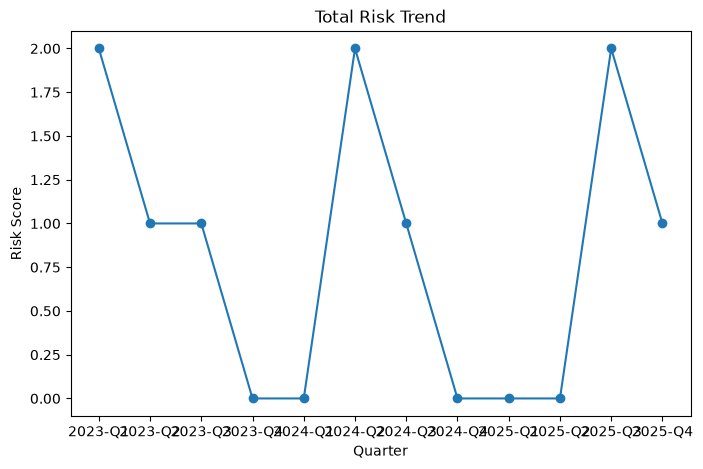

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(risk_df["quarter"], risk_df["total_risk_score"], marker="o")

plt.title("Total Risk Trend")

plt.xlabel("Quarter")

plt.ylabel("Risk Score")

plt.show()

In [20]:
risk_df[risk_columns].sum()

inflation_risk       2
supply_chain_risk    1
regulatory_risk      2
currency_risk        3
competition_risk     2
dtype: int64

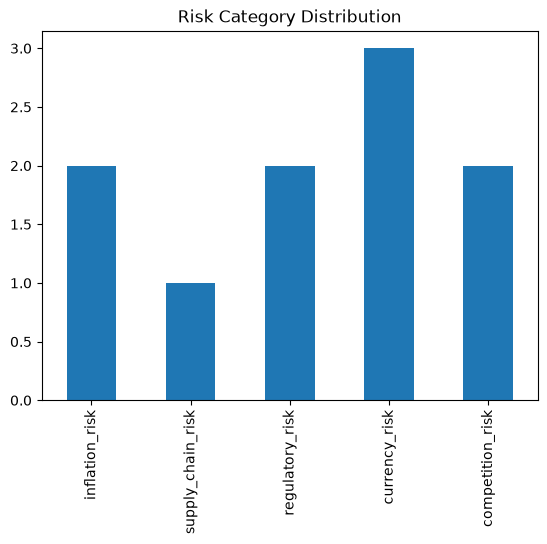

In [21]:
risk_df[risk_columns].sum().plot(kind="bar")

plt.title("Risk Category Distribution")

plt.show()

In [22]:
risk_df = pd.merge(risk_df, financial_df[["quarter", "revenue_million"]], on="quarter")

In [23]:
risk_df[["quarter", "total_risk_score", "revenue_million"]]

,quarter,total_risk_score,revenue_million
0,2023-Q1,2,120
1,2023-Q2,1,128
2,2023-Q3,1,138
3,2023-Q4,0,150
4,2024-Q1,0,158
5,2024-Q2,2,167
6,2024-Q3,1,174
7,2024-Q4,0,190
8,2025-Q1,0,198
9,2025-Q2,0,210


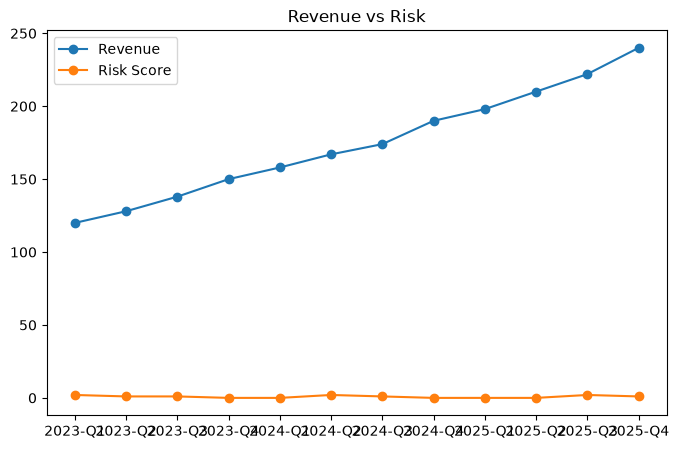

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(risk_df["quarter"], risk_df["revenue_million"], marker="o", label="Revenue")

plt.plot(
    risk_df["quarter"], risk_df["total_risk_score"], marker="o", label="Risk Score"
)

plt.legend()

plt.title("Revenue vs Risk")

plt.show()

In [25]:
max_score = risk_df["total_risk_score"].max()

risk_df["normalized_risk_score"] = risk_df["total_risk_score"] / max_score

In [26]:
risk_df[["quarter", "normalized_risk_score"]]

,quarter,normalized_risk_score
0,2023-Q1,1.0
1,2023-Q2,0.5
2,2023-Q3,0.5
3,2023-Q4,0.0
4,2024-Q1,0.0
5,2024-Q2,1.0
6,2024-Q3,0.5
7,2024-Q4,0.0
8,2025-Q1,0.0
9,2025-Q2,0.0


In [27]:
financial_risk_df = pd.merge(
    financial_df,
    risk_df[["quarter", "total_risk_score", "normalized_risk_score"]],
    on="quarter",
)

In [28]:
financial_risk_df.head()

,ticker,quarter,revenue_million,gross_margin_pct,operating_income_million,net_income_million,eps,earnings_call,risk_factors,mda_section,...,character_count,sentences,chunks,sentiment,confidence,weighted_sentiment,guidance_score,positive_guidance_score,total_risk_score,normalized_risk_score
0,ABC,2023-Q1,120,58,22,16,1.20,\n Demand remained strong across enterp...,\n Inflation remains a concern.\n ...,\n Management believes demand trends re...,...,299,['Demand remained strong across enterprise cus...,['Demand remained strong across enterprise cus...,positive,0.956167,0.956167,1,1,2,1.0
1,ABC,2023-Q2,128,60,25,18,1.35,\n Enterprise adoption accelerated.\n ...,\n Competitive pressure exists.\n ...,\n New product launches contributed pos...,...,239,"['Enterprise adoption accelerated.', 'Pricing ...",['Enterprise adoption accelerated. Pricing pre...,positive,0.957692,0.957692,1,2,1,0.5
2,ABC,2023-Q3,138,61,28,21,1.52,\n Customer demand exceeded expectation...,\n Geopolitical uncertainty remains.\n ...,\n Strong customer growth across region...,...,269,"['Customer demand exceeded expectations.', 'Su...",['Customer demand exceeded expectations. Suppl...,positive,0.951876,0.951876,2,0,1,0.5
3,ABC,2023-Q4,150,63,32,24,1.72,\n Record quarter performance.\n ...,\n Macroeconomic slowdown remains possi...,\n Revenue growth exceeded internal exp...,...,260,"['Record quarter performance.', 'Management ex...",['Record quarter performance. Management expec...,positive,0.956653,0.956653,1,1,0,0.0
4,ABC,2024-Q1,158,62,34,26,1.85,\n Strong start to the fiscal year driv...,\n Increased cyber security threats req...,\n Gross margin slightly contracted due...,...,460,['Strong start to the fiscal year driven by en...,['Strong start to the fiscal year driven by en...,positive,0.922371,0.922371,1,0,0,0.0


In [29]:
risk_df.to_csv("../data/risk_factor_analysis.csv", index=False)

In [30]:
financial_risk_df.to_csv("../data/financial_risk_dataset.csv", index=False)

In [31]:
saved_df = pd.read_csv("../data/risk_factor_analysis.csv")

saved_df.head()

,ticker,quarter,inflation_risk,supply_chain_risk,regulatory_risk,currency_risk,competition_risk,total_risk_score,revenue_million,normalized_risk_score
0,ABC,2023-Q1,1,1,0,0,0,2,120,1.0
1,ABC,2023-Q2,0,0,0,1,0,1,128,0.5
2,ABC,2023-Q3,0,0,1,0,0,1,138,0.5
3,ABC,2023-Q4,0,0,0,0,0,0,150,0.0
4,ABC,2024-Q1,0,0,0,0,0,0,158,0.0
